# Used Car Price Prediction — Regression Modeling

This notebook builds, evaluates, and tunes regression models to predict the price of used cars
from their listed characteristics (brand, model, age, mileage, engine specs, condition, etc.).

**How this version is organized.** This is a restructured version of the original notebook, split
so that **every code cell performs exactly one operation** (one computation, one print, one plot),
with a short markdown explanation directly above each cell describing what it does and why. The
overall project sequence is unchanged, and one addition has been made: **XGBoost** is now included
alongside the original candidate models, and it goes through the same cross-validation process as
the rest.

The short version of how the steps are ordered:

- **Cleaning happens before "explore the target variable"**, because `price` and `milage` arrive
  as text (`"$10,300"`, `"51,000 mi."`) — they must be converted to numbers before any
  distribution or correlation can be computed.
- **Outlier investigation happens right after exploring the target**, since the target's
  distribution is exactly where outliers first become visible, and the outlier decision then
  informs the EDA/encoding steps that follow.
- **Feature scaling and encoding are combined into a single `ColumnTransformer`** placed inside a
  scikit-learn `Pipeline`, fit fresh inside every cross-validation fold, to avoid data leakage.
- **Cross-validation is used for model comparison**, and the held-out test set is reserved for one
  final, honest evaluation of the winning model after tuning.
- **The top two models from cross-validation both get hyperparameter-tuned**, and only then is a
  single final model chosen — whichever two algorithms actually come out on top get the tuning
  budget, rather than assuming in advance that it will be a particular pair (e.g. the two gradient
  boosting variants). XGBoost is evaluated on equal footing with everything else, but it only
  advances to tuning if the cross-validated numbers actually put it in the top two.

## 0. Imports & Global Settings

Load every library used anywhere in the notebook up front, and fix a random seed so every
downstream split, shuffle, and model fit is reproducible.

In [1]:
import pandas as pd
import numpy as np
import re

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 160)

In [4]:
sns.set_theme(style='whitegrid', palette='muted')

In [5]:
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 1. Load & Understand the Dataset

First pass: shape, column types, and a peek at the raw rows, before touching anything.

In [6]:
df_raw = pd.read_csv('used_cars.csv')

In [7]:
print(f"Rows: {df_raw.shape[0]}, Columns: {df_raw.shape[1]}")

Rows: 4009, Columns: 12


In [8]:
df_raw.head()

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,Ford,Utility Police Interceptor Base,2013,"51,000 mi.",E85 Flex Fuel,300.0HP 3.7L V6 Cylinder Engine Flex Fuel Capa...,6-Speed A/T,Black,Black,At least 1 accident or damage reported,Yes,"$10,300"
1,Hyundai,Palisade SEL,2021,"34,742 mi.",Gasoline,3.8L V6 24V GDI DOHC,8-Speed Automatic,Moonlight Cloud,Gray,At least 1 accident or damage reported,Yes,"$38,005"
2,Lexus,RX 350 RX 350,2022,"22,372 mi.",Gasoline,3.5 Liter DOHC,Automatic,Blue,Black,None reported,NaN,"$54,598"
3,INFINITI,Q50 Hybrid Sport,2015,"88,900 mi.",Hybrid,354.0HP 3.5L V6 Cylinder Engine Gas/Electric H...,7-Speed A/T,Black,Black,None reported,Yes,"$15,500"
4,Audi,Q3 45 S line Premium Plus,2021,"9,835 mi.",Gasoline,2.0L I4 16V GDI DOHC Turbo,8-Speed Automatic,Glacier White Metallic,Black,None reported,NaN,"$34,999"


In [9]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 4009 entries, 0 to 4008
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   brand         4009 non-null   str  
 1   model         4009 non-null   str  
 2   model_year    4009 non-null   int64
 3   milage        4009 non-null   str  
 4   fuel_type     3839 non-null   str  
 5   engine        4009 non-null   str  
 6   transmission  4009 non-null   str  
 7   ext_col       4009 non-null   str  
 8   int_col       4009 non-null   str  
 9   accident      3896 non-null   str  
 10  clean_title   3413 non-null   str  
 11  price         4009 non-null   str  
dtypes: int64(1), str(11)
memory usage: 376.0 KB


In [10]:
df_raw.describe()

,model_year
count,4009.000000
mean,2015.515590
std,6.104816
min,1974.000000
25%,2012.000000
50%,2017.000000
75%,2020.000000
max,2024.000000


**Observations from the raw data:**
- price and milage are stored as text with "$", commas, and a  "mi". suffix — they need to
  be parsed into numbers before they're usable at all.
- engine is a free-text description (e.g. 300.0HP 3.7L V6 Cylinder Engine Flex Fuel
  Capability) that actually bundles three useful numeric signals: horsepower, engine
  displacement (liters), and cylinder count. Worth extracting rather than dropping or one-hot
  encoding as-is (it has 1,146 unique strings).
- brand, model, ext_col (exterior color), int_col (interior color) and transmission are
  categorical text fields with widely varying cardinality — checked properly later.
- model_year ranges from 1974 to 2024, so a derived car_age will likely be more directly
  useful to a model than the raw year.

## 2. Missing Values — Identify & Investigate

Only three columns have missing values in the raw data. Look at *how much* is missing and
*why* it's plausibly missing before deciding how to handle each one (that decision is applied
later, in the cleaning step, once `price`/`milage` parsing is also in place).

In [11]:
missing = df_raw.isna().sum()
missing 

brand             0
model             0
model_year        0
milage            0
fuel_type       170
engine            0
transmission      0
ext_col           0
int_col           0
accident        113
clean_title     596
price             0
dtype: int64

Next, look at the *raw values* behind each of the three columns with missing data — not just the
NaN count — since some "missingness" is actually a differently-spelled placeholder rather than a
true NaN.

In [12]:
df_raw['fuel_type'].value_counts(dropna=False)

fuel_type
Gasoline          3309
Hybrid             194
NaN                170
E85 Flex Fuel      139
Diesel             116
–                   45
Plug-In Hybrid      34
not supported        2
Name: count, dtype: int64

In [13]:
df_raw['accident'].value_counts(dropna=False)

accident
None reported                             2910
At least 1 accident or damage reported     986
NaN                                        113
Name: count, dtype: int64

In [14]:
df_raw['clean_title'].value_counts(dropna=False)

clean_title
Yes    3413
NaN     596
Name: count, dtype: int64

**Investigation & decisions (applied in Section 5):**
- fuel_type (170 NaN) also has "–" (45 rows) and "not supported" (2 rows), which are really
  the same kind of missingness spelled differently by the source listing tool — not real fuel
  types. These will all be unified. Some of these rows are actually electric vehicles (an
  "Electric Motor" engine but a blank fuel type) — recoverable from the "engine" text — the rest
  become an explicit "Unknown" category rather than being imputed to the majority class
  , since guessing the fuel type would fabricate information the seller genuinely didn't
  provide.
- "accident" (113 NaN) — the seller either didn't answer or the field wasn't scraped. Since
  "no answer" is meaningfully different from a confirmed "None reported", this becomes its own
  "Unknown" category rather than being merged into either existing class.
- "clean_title" (596 NaN) — the column only ever contains the value "Yes", i.e. it's really a
  one-sided flag ("clean title confirmed" vs. "not confirmed/unknown"), so missing is recoded as
  its own level of a "clean_title_flag" binary rather than imputed.

None of the three missing-value columns are dropped: missingness itself is informative here (a
listing lacking accident/title information is a real, common category in the used-car market, not
noise), so encoding it as an explicit category preserves that signal for the model.

## 3. Duplicate Rows

A quick full-row duplicate check before doing any further work.

In [15]:
df_raw.duplicated().sum()

np.int64(0)

No duplicate rows — nothing to drop here.

## 4. Categorical Variables — Cardinality Check

Before deciding how to encode anything, check how many distinct values each categorical column
has. This directly drives the encoding strategy in Section 11: low-cardinality nominal columns are
good candidates for one-hot encoding, while very high-cardinality columns (hundreds to thousands
of levels) would blow up a one-hot matrix and are better target-encoded.

In [16]:
cat_cols = ['brand', 'model', 'fuel_type', 'engine', 'transmission', 'ext_col', 'int_col', 'accident', 'clean_title']

In [17]:
card = pd.DataFrame({
    'n_unique': [df_raw[c].nunique() for c in cat_cols],
    'dtype': [df_raw[c].dtype for c in cat_cols]
}, index=cat_cols).sort_values('n_unique')

In [18]:
card

,n_unique,dtype
clean_title,1,str
accident,2,str
fuel_type,7,str
brand,57,str
transmission,62,str
int_col,156,str
ext_col,319,str
engine,1146,str
model,1898,str


In [19]:
df_raw['brand'].value_counts().head(10)

brand
Ford             386
BMW              375
Mercedes-Benz    315
Chevrolet        292
Porsche          201
Audi             200
Toyota           199
Lexus            163
Jeep             143
Land             130
Name: count, dtype: int64

In [20]:
df_raw['transmission'].value_counts().head(10)

transmission
A/T                               1037
8-Speed A/T                        406
Transmission w/Dual Shift Mode     398
6-Speed A/T                        362
6-Speed M/T                        248
Automatic                          237
7-Speed A/T                        209
8-Speed Automatic                  176
10-Speed A/T                       119
5-Speed A/T                         86
Name: count, dtype: int64

In [21]:
df_raw['engine'].value_counts().head(10)

engine
2.0L I4 16V GDI DOHC Turbo                               52
355.0HP 5.3L 8 Cylinder Engine Gasoline Fuel             48
420.0HP 6.2L 8 Cylinder Engine Gasoline Fuel             47
–                                                        45
300.0HP 3.0L Straight 6 Cylinder Engine Gasoline Fuel    44
240.0HP 2.0L 4 Cylinder Engine Gasoline Fuel             42
285.0HP 3.6L V6 Cylinder Engine Gasoline Fuel            40
5.7L V8 16V MPFI OHV                                     29
340.0HP 3.0L V6 Cylinder Engine Gasoline Fuel            28
3.6L V6 24V MPFI DOHC                                    28
Name: count, dtype: int64

**Reading on cardinality:**
- `clean_title` (1 real level) and `accident` (2 levels) and `fuel_type` (~5-7 clean levels) are
  low-cardinality nominal → one-hot encoding.
- `transmission` has 62 raw strings but they're mostly redundant spellings of a few real ideas
  (automatic / manual / CVT / dual-shift automatic) → bucket it down to ~5 categories in cleaning,
  then one-hot encode the bucketed version.
- `brand` (57), `model` (1,898), `ext_col` (319), `int_col` (156) and `engine` (1,146) are high
  cardinality. `engine` gets parsed into numeric sub-features later instead of being encoded
  as text. The other four are handled with target encoding later.

## 5. Data Cleaning & Feature Engineering

This is the step that turns the raw, text-heavy columns into something a regression model can use,
and where the missing-value decisions from Section 2 are actually applied. This happens before
exploring `price` itself because the target has to be numeric first.

**Decisions made here, with reasoning:**

1. **`price`**: strip `$` and `,`, cast to float. This is the target variable.
2. **`milage`**: strip `" mi."` and `,`, cast to float.
3. **`engine` → three numeric features + three "was-missing" flags**: regex-parse horsepower
   (`horsepower`), engine displacement in liters (`engine_liters`), and cylinder count
   (`cylinders`) out of the free-text engine description, plus an `is_electric` flag. Roughly
   a lot of listings don't state horsepower in the text. Critically, this **isn't missing at
   random**  So instead of silently imputing
   and hiding a pattern, binary `*_missing` indicator columns are added before median-imputing
   the values themselves — that way the model can still use the fact that a value was missing as
   its own signal.
4. **`car_age`**: `2024 − model_year`. A car's age is generally a more directly
   interpretable price driver than its absolute model year.
5. **`transmission` → `transmission_group`**: collapse the 62 raw strings down to 5 buckets
   (`Automatic`, `Dual-Shift Automatic`, `Manual`, `CVT`, `Other/Unknown`) since most of the raw
   variety was just different manufacturers' naming of the same underlying transmission type.
6. **`fuel_type`**: unify `"–"` and `"not supported"` into `NaN`, recover `"Electric"` for rows
   the engine text confirms are electric, and fill any remaining gaps with an explicit
   `"Unknown"` category .
7. **`accident`**: fill missing with `"Unknown"` .
8. **`clean_title` → `clean_title_flag`**: recode to `"Yes"` vs `"No/Unknown"` .

The original `engine`, `transmission`, and `clean_title` text columns are kept for now so they remain available for transparency during EDA.

In [22]:
df = df_raw.copy()

Parse `price` from text (`"$10,300"`) into a float column.

In [23]:
df['price'] = df['price'].str.replace('$', '', regex=False).str.replace(',', '', regex=False).astype(float)

Parse `milage` from text (`"51,000 mi."`) into a float column.

In [24]:
df['milage'] = df['milage'].str.replace(' mi.', '', regex=False).str.replace(',', '', regex=False).astype(float)

Define small regex helper functions to pull horsepower, displacement (liters), and cylinder count out of the free-text `engine` column.

In [25]:
def get_hp(s):
    m = re.search(r'([\d\.]+)\s*HP', s)
    return float(m.group(1)) if m else np.nan

def get_liters(s):
    m = re.search(r'([\d\.]+)\s*L(?:iter)?\b', s)
    return float(m.group(1)) if m else np.nan

def get_cylinders(s):
    m = re.search(r'(\d+)\s*Cylinder', s)
    if m:
        return float(m.group(1))
    m = re.search(r'\bV(\d+)\b', s)
    if m:
        return float(m.group(1))
    m = re.search(r'\bI(\d+)\b', s)
    if m:
        return float(m.group(1))
    if 'Electric' in s:
        return 0.0
    return np.nan

Flag electric vehicles directly from the `engine` text (used both as a feature and to correctly handle liters/cylinders below).

In [26]:
df['is_electric'] = df['engine'].str.contains('Electric', case=False).astype(int)

Apply the horsepower parser to create the `horsepower` column.

In [27]:
df['horsepower'] = df['engine'].apply(get_hp)

Apply the liters parser to create the `engine_liters` column.

In [28]:
df['engine_liters'] = df['engine'].apply(get_liters)

Apply the cylinder parser to create the `cylinders` column.

In [29]:
df['cylinders'] = df['engine'].apply(get_cylinders)

Electric cars legitimately have 0 liters of displacement — fill only their (structural, not random) missing `engine_liters` with 0.

In [30]:
df.loc[df['is_electric'] == 1, 'engine_liters'] = df.loc[df['is_electric'] == 1, 'engine_liters'].fillna(0.0)

Same reasoning for `cylinders`: an electric motor genuinely has 0 cylinders, not a missing value.

In [31]:
df.loc[df['is_electric'] == 1, 'cylinders'] = df.loc[df['is_electric'] == 1, 'cylinders'].fillna(0.0)

Before imputing anything else, record **whether horsepower was missing** as its own binary flag — this is the informative-missingness signal described above.

In [32]:
df['hp_missing'] = df['horsepower'].isna().astype(int)

Same missingness flag for `engine_liters`.

In [33]:
df['liters_missing'] = df['engine_liters'].isna().astype(int)

Same missingness flag for `cylinders`.

In [34]:
df['cyl_missing'] = df['cylinders'].isna().astype(int)

### Deciding how to fill missing `engine_size` , `horsepower` and `cylinders`

Before filling, we look at the **distribution shape** (histogram + skewness) of each column, because that tells us whether the mean, median, or mode is the most appropriate fill value:
- If a column is roughly symmetric (low skew), the **mean** is a fine, efficient summary.
- If a column is skewed or has extreme values pulling the mean around, the **median** is more robust/representative.
- The **mode** is mainly appropriate for categorical or discrete columns with a small number of repeating values, not continuous measurements like these.

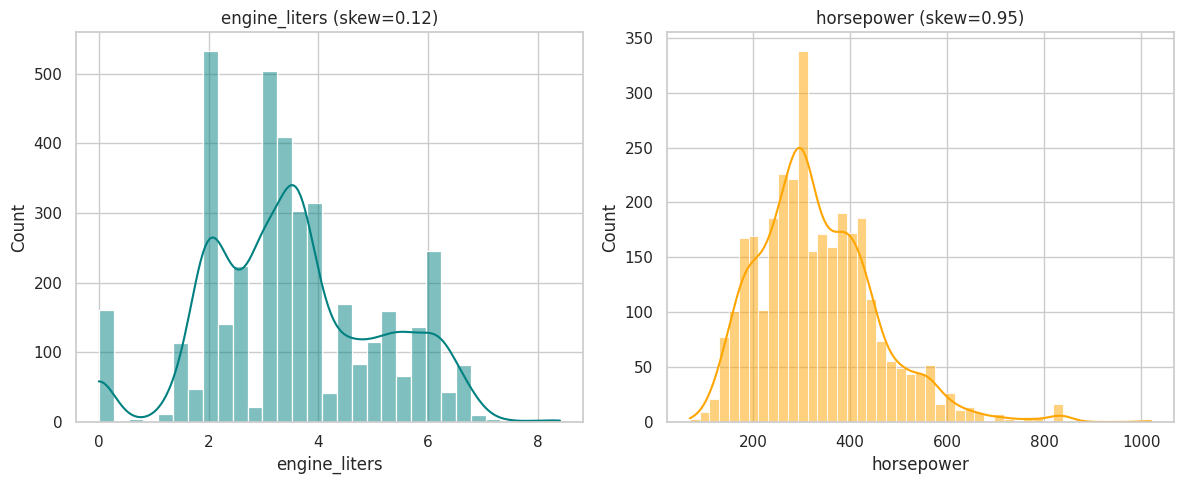

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(df["engine_liters"].dropna(), kde=True, ax=axes[0], color="teal")
axes[0].set_title(f"engine_liters (skew={df['engine_liters'].skew():.2f})")
sns.histplot(df["horsepower"].dropna(), kde=True, ax=axes[1], color="orange")
axes[1].set_title(f"horsepower (skew={df['horsepower'].skew():.2f})")

plt.tight_layout()
plt.show()

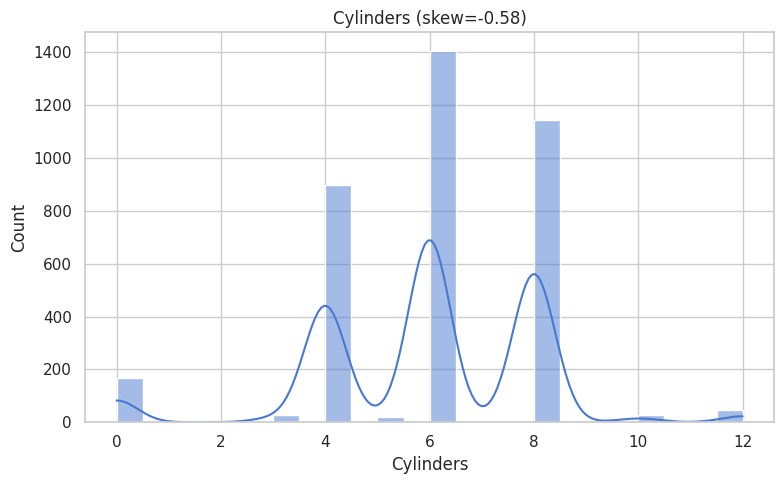

In [36]:
plt.figure(figsize=(8, 5))

sns.histplot(df["cylinders"].dropna(), kde=True)

plt.title(f"Cylinders (skew={df['cylinders'].skew():.2f})")
plt.xlabel("Cylinders")
plt.ylabel("Count")

plt.tight_layout()
plt.show()

Now that the missingness flags are safely captured, median-impute the remaining gaps in the three engine-spec numeric columns.

In [37]:
for col in ['horsepower', 'engine_liters', 'cylinders']:
    df[col] = df[col].fillna(df[col].median())

Derive `car_age` from `model_year`, since age is generally a more directly useful predictor than an absolute year.

In [38]:
df['car_age'] = 2024 - df['model_year']

Define a helper that buckets the 62 raw `transmission` strings down into 5 meaningful groups.

In [39]:
def bucket_transmission(s):
    s = str(s)
    if 'CVT' in s:
        return 'CVT'
    if 'M/T' in s or 'Manual' in s:
        return 'Manual'
    if 'Dual Shift' in s or 'Dual-Shift' in s:
        return 'Dual-Shift Automatic'
    if 'A/T' in s or 'Automatic' in s:
        return 'Automatic'
    return 'Other/Unknown'

Apply the bucketing helper to create `transmission_group`.

In [40]:
df['transmission_group'] = df['transmission'].apply(bucket_transmission)

Unify the placeholder spellings of missing `fuel_type` (`"–"`, `"not supported"`) into a real `NaN`.

In [41]:
df['fuel_type'] = df['fuel_type'].replace({'–': np.nan, 'not supported': np.nan})

Recover `"Electric"` as the fuel type for rows the `engine` text already confirms are electric.

In [42]:
df.loc[df['is_electric'] == 1, 'fuel_type'] = df.loc[df['is_electric'] == 1, 'fuel_type'].fillna('Electric')

Fill any still-remaining `fuel_type` gaps with an explicit `"Unknown"` category, rather than guessing.

In [43]:
df['fuel_type'] = df['fuel_type'].fillna('Unknown')

Fill missing `accident` values with an explicit `"Unknown"` category.

In [44]:
df['accident'] = df['accident'].fillna('Unknown')

Recode `clean_title` into a cleaner binary `clean_title_flag` (`"Yes"` vs. `"No/Unknown"`).

In [45]:
df['clean_title_flag'] = np.where(df['clean_title'] == 'Yes', 'Yes', 'No/Unknown')

Sanity-check the newly engineered columns.

In [46]:
df[['horsepower', 'engine_liters', 'cylinders', 'hp_missing', 'liters_missing', 'cyl_missing',
    'car_age', 'transmission_group', 'fuel_type', 'accident', 'clean_title_flag']].head()

,horsepower,engine_liters,cylinders,hp_missing,liters_missing,cyl_missing,car_age,transmission_group,fuel_type,accident,clean_title_flag
0,300.0,3.7,6.0,0,0,0,11,Automatic,E85 Flex Fuel,At least 1 accident or damage reported,Yes
1,310.0,3.8,6.0,1,0,0,3,Automatic,Gasoline,At least 1 accident or damage reported,Yes
2,310.0,3.5,6.0,1,0,1,2,Automatic,Gasoline,None reported,No/Unknown
3,354.0,3.5,6.0,0,0,0,9,Automatic,Hybrid,None reported,Yes
4,310.0,2.0,4.0,1,0,0,3,Automatic,Gasoline,None reported,No/Unknown


Confirm no unexpected nulls remain anywhere in the dataframe after cleaning.

In [47]:
df.isna().sum()[df.isna().sum() > 0]

clean_title    596
dtype: int64

Check the resulting distribution of the new `transmission_group` buckets.

In [48]:
df['transmission_group'].value_counts()

transmission_group
Automatic               3109
Dual-Shift Automatic     398
Manual                   374
CVT                      100
Other/Unknown             28
Name: count, dtype: int64

## 6. Explore the Target Variable (`price`)

Now that `price` is numeric, its distribution can be looked at directly.

In [49]:
df['price'].describe()

count    4.009000e+03
mean     4.455319e+04
std      7.871064e+04
min      2.000000e+03
25%      1.720000e+04
50%      3.100000e+04
75%      4.999000e+04
max      2.954083e+06
Name: price, dtype: float64

`price` is extremely right-skewed (skew ≈ 12.9 before cleaning up the one bad record found
below): the bulk of cars sell in the $2K–$100K range, but a handful of exotic cars pull the tail
out to millions of dollars. `log1p(price)` brings the skew down close to 0. This is the basis for
the modeling decision  to train on `log1p(price)` and invert the transform at
prediction time — it keeps a $2,000 error on a $10,000 car and a $2,000 error on a $500,000 car
from being treated as equally "small" by the loss function, and it also makes the target
distribution far more compatible with a linear model's assumptions.

Check the skewness of raw `price`, and how much a `log1p` transform would reduce it.

In [50]:
print(f"Skewness of raw price: {df['price'].skew():.2f}")
print(f"Skewness of log1p(price): {np.log1p(df['price']).skew():.2f}")

Skewness of raw price: 19.51
Skewness of log1p(price): 0.11


Plot both distributions side by side to see the effect of the log transform visually.

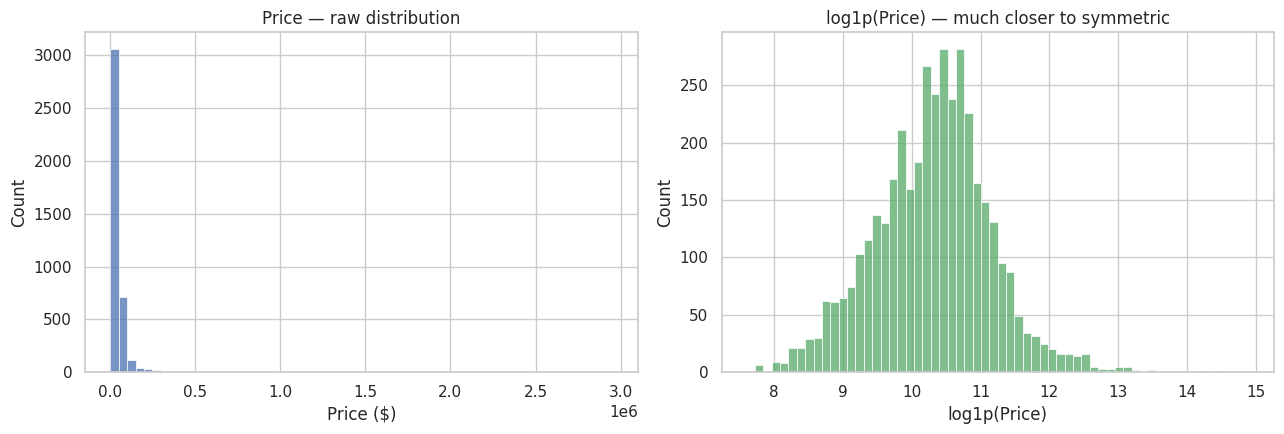

In [51]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sns.histplot(df['price'], bins=60, ax=axes[0], color='#4C72B0')
axes[0].set_title('Price — raw distribution')
axes[0].set_xlabel('Price ($)')

sns.histplot(np.log1p(df['price']), bins=60, ax=axes[1], color='#55A868')
axes[1].set_title('log1p(Price) — much closer to symmetric')
axes[1].set_xlabel('log1p(Price)')

plt.tight_layout()
plt.show()

## 7. Outlier Investigation

Since prices span 3 orders of magnitude, the goal here is to separate *legitimate* expensive cars
(Bugattis and Rolls-Royces are genuinely expensive) from actual **data errors**.

In [52]:
df.nlargest(15, 'price')[['brand', 'model', 'model_year', 'price']]

,brand,model,model_year,price
693,Maserati,Quattroporte Base,2005,2954083.0
229,Bugatti,Veyron 16.4 Grand Sport,2011,1950995.0
3046,Porsche,Carrera GT Base,2005,1599000.0
1356,Lamborghini,Aventador SVJ Base,2021,749950.0
624,Rolls-Royce,Cullinan,2022,695000.0
979,Lamborghini,Aventador SVJ Base,2019,649999.0
1615,Rolls-Royce,Phantom,2023,599995.0
1508,Rolls-Royce,Phantom,2018,599000.0
3655,Lamborghini,Aventador S Base,2018,491836.0
1061,Dodge,Viper GTC,2017,489995.0


The Maserati Quattroporte jumps out as implausible relative to every other Quattroporte listing — cross-check against the other Quattroporte rows in the dataset.

In [53]:
df[df['model'].str.contains('Quattroporte', case=False)][['brand', 'model', 'model_year', 'price']].sort_values('price', ascending=False)

,brand,model,model_year,price
693,Maserati,Quattroporte Base,2005,2954083.0
843,Maserati,Quattroporte Modena Q4,2023,125900.0
77,Maserati,Quattroporte S,2019,44999.0
884,Maserati,Quattroporte S Q4 GranLusso,2018,41900.0
1354,Maserati,Quattroporte S GranLusso,2017,39100.0
2514,Maserati,Quattroporte S,2012,26497.0
2355,Maserati,Quattroporte Base,2006,18000.0
1143,Maserati,Quattroporte Base,2006,16500.0
1060,Maserati,Quattroporte Sport GT,2007,7999.0


**Finding:** every other Maserati Quattroporte in the dataset — including a 2006 model, one
year newer than the flagged row — sold in the **$7,999–$44,999** range. The single row priced at
**$2,954,083** for a 2005 base Quattroporte is not a real price; it's almost certainly a data-entry
error (an extra digit or two). Everything else in the top 15 is a real, correctly-priced exotic/luxury
car and stays in the dataset — those cars really do cost that much, and a price-prediction model
should be able to represent them.

**Decision:** remove only the one implausible Quattroporte row. The `log1p` target transform decided on in Section 6 is what actually keeps these
legitimate high-price points from destabilizing the linear models, rather than removing the data.

Remove only the single implausible Maserati Quattroporte row identified above.

In [54]:
df = df[~((df['brand'] == 'Maserati') & (df['model'] == 'Quattroporte Base') & (df['price'] > 1_000_000))].copy()

In [55]:

print(f"Remaining rows: {len(df)}")

Remaining rows: 4008


## 8. EDA — Relationships with Price

With the target cleaned and the obvious data error removed, look at how each feature relates to
price.

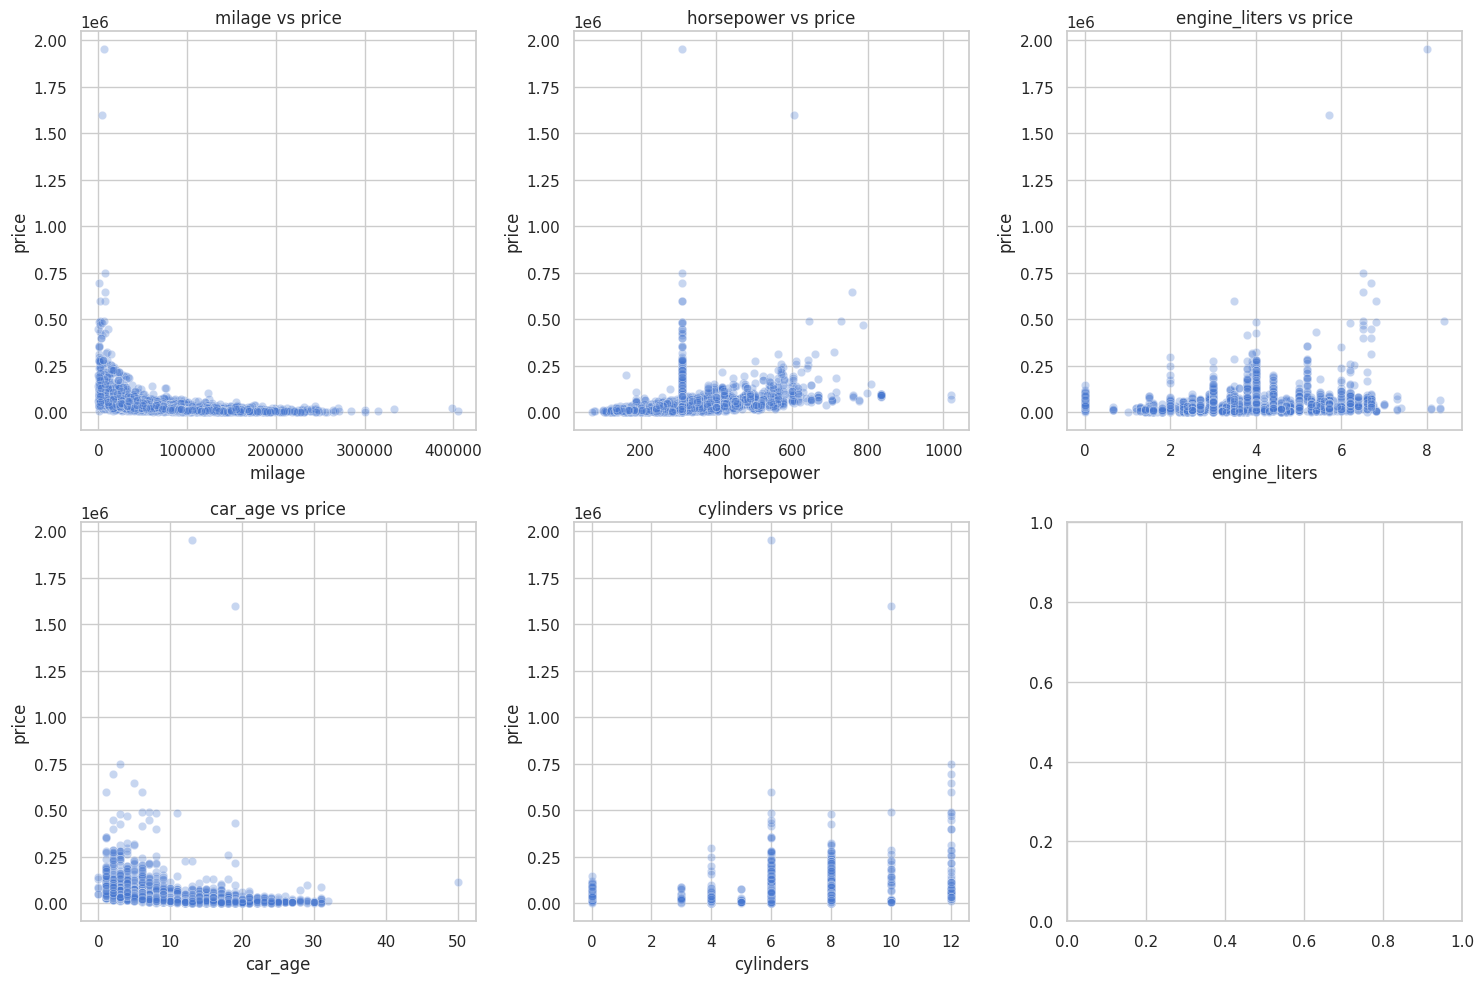

In [56]:
numeric_cols = ["milage", "horsepower", "engine_liters", "car_age", "cylinders"]
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
for ax, col in zip(axes.flatten(), numeric_cols):
    sns.scatterplot(x=df[col], y=df["price"], alpha=0.3, ax=ax)
    ax.set_title(f"{col} vs price")
plt.tight_layout()
plt.show()

Build the correlation matrix among the numeric features and price.

In [57]:
numeric_cols_for_corr = ['price', 'milage', 'horsepower', 'engine_liters', 'cylinders', 'car_age']
corr = df[numeric_cols_for_corr].corr()

Plot the correlation matrix as a heatmap.

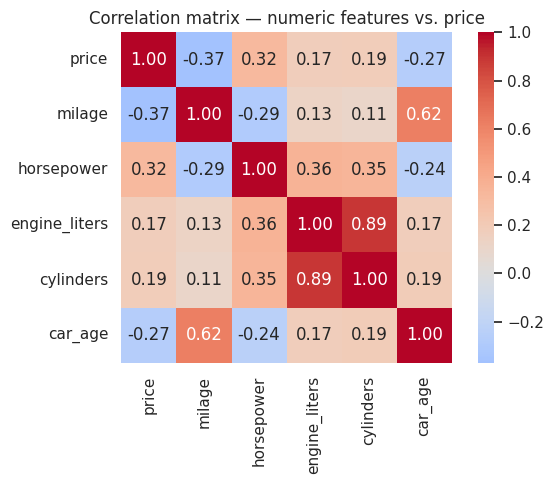

In [58]:
plt.figure(figsize=(6.5, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Correlation matrix — numeric features vs. price')
plt.tight_layout()
plt.show()

`horsepower` (+0.63) is the strongest linear correlate of price, followed by `car_age`
(−0.43) and `milage` (−0.38, and it's also correlated with `car_age` at 0.82 — older cars simply
have more miles on them, which is worth keeping in mind for the tree-based models, which handle
correlated features gracefully, and the linear ones, which will each get a smaller share of the
credit split between the two).

Take a manageable random sample and plot price (log scale) against mileage and against car age.

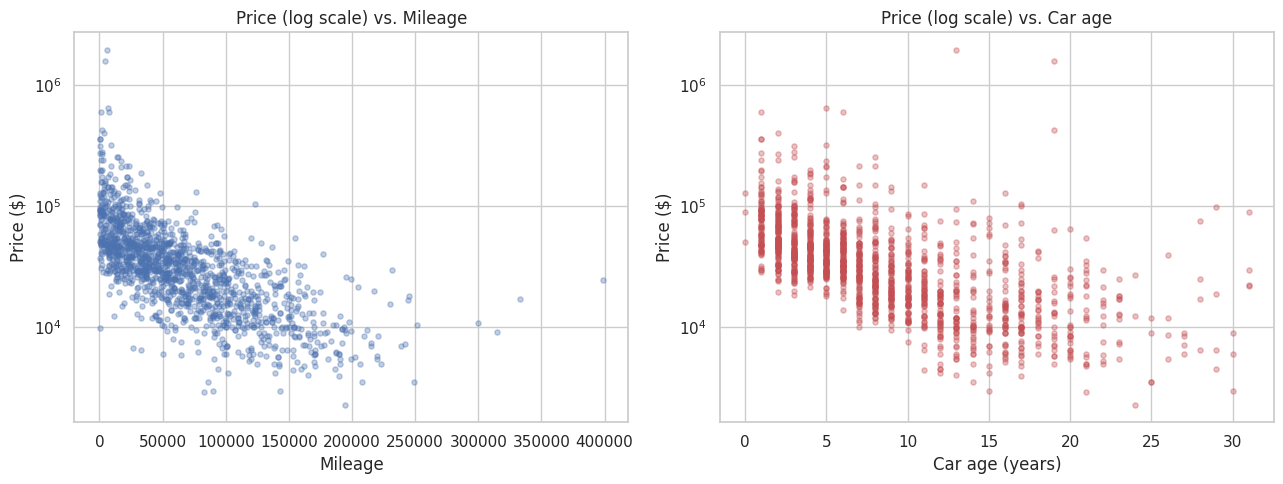

In [59]:
sample = df.sample(min(1500, len(df)), random_state=RANDOM_STATE)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(sample['milage'], sample['price'], alpha=0.35, s=14, color='#4C72B0')
axes[0].set_xlabel('Mileage'); axes[0].set_ylabel('Price ($)'); axes[0].set_yscale('log')
axes[0].set_title('Price (log scale) vs. Mileage')

axes[1].scatter(sample['car_age'], sample['price'], alpha=0.35, s=14, color='#C44E52')
axes[1].set_xlabel('Car age (years)'); axes[1].set_ylabel('Price ($)'); axes[1].set_yscale('log')
axes[1].set_title('Price (log scale) vs. Car age')

plt.tight_layout()
plt.show()

Compare price distributions across the 12 most commonly listed brands.

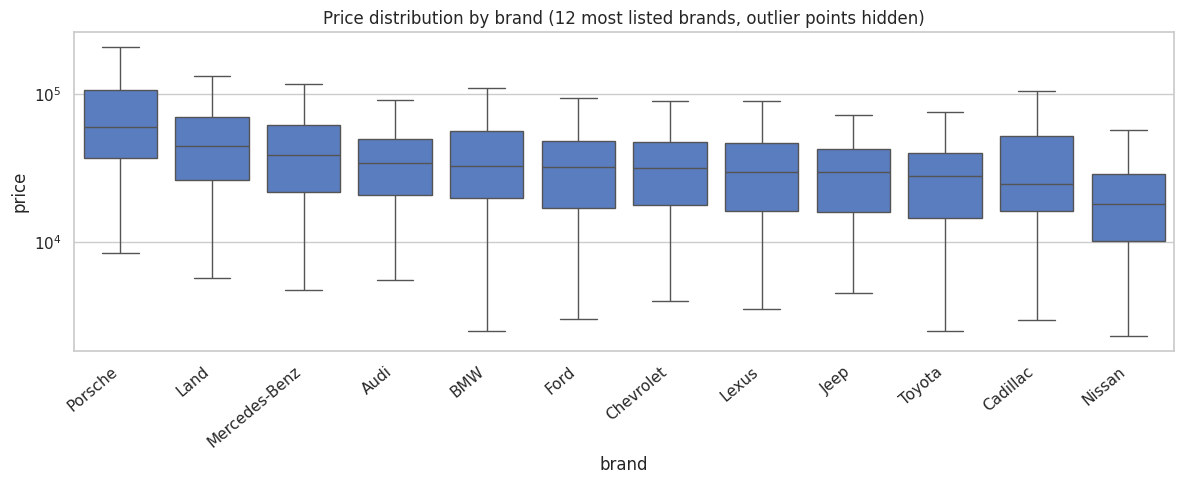

In [60]:
top_brands = df['brand'].value_counts().head(12).index
order = df[df['brand'].isin(top_brands)].groupby('brand')['price'].median().sort_values(ascending=False).index

plt.figure(figsize=(12, 5))
sns.boxplot(data=df[df['brand'].isin(top_brands)], x='brand', y='price', order=order, showfliers=False)
plt.yscale('log')
plt.xticks(rotation=40, ha='right')
plt.title('Price distribution by brand (12 most listed brands, outlier points hidden)')
plt.tight_layout()
plt.show()

Compare price distributions by accident history and by fuel type.

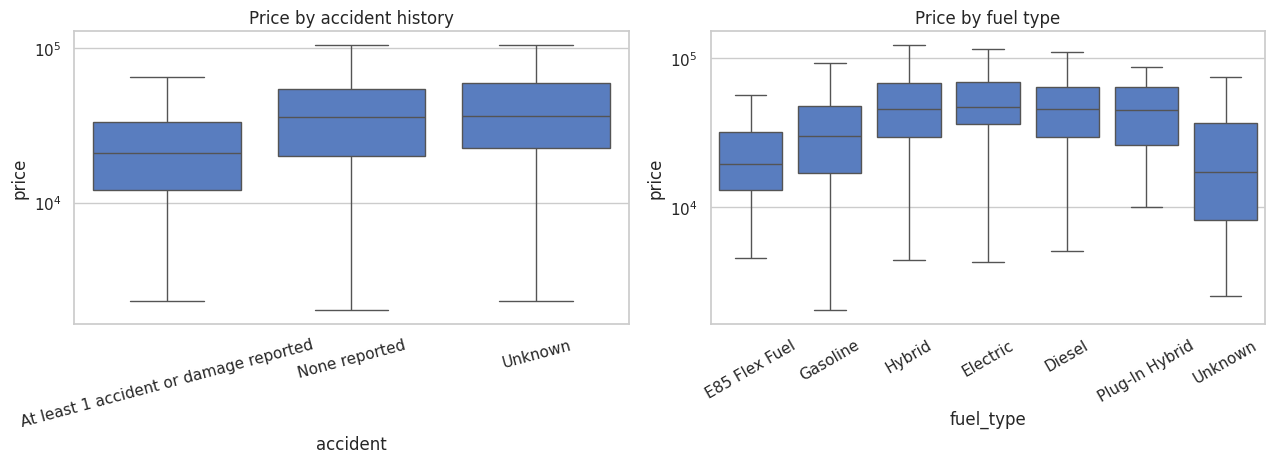

In [61]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

sns.boxplot(data=df, x='accident', y='price', ax=axes[0], showfliers=False)
axes[0].set_yscale('log'); axes[0].set_title('Price by accident history')
axes[0].tick_params(axis='x', rotation=15)

sns.boxplot(data=df, x='fuel_type', y='price', ax=axes[1], showfliers=False)
axes[1].set_yscale('log'); axes[1].set_title('Price by fuel type')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

**EDA takeaways:**
- Mileage and car age both show the expected negative relationship with price (note the log
  y-axis — the relationship is closer to exponential decay than linear, which is another point in
  favor of modeling `log(price)`).
- Brand matters a lot — median prices for the 12 most-listed brands span roughly an order of
  magnitude, which justifies keeping `brand` (and the even more granular `model`) as real
  predictive features rather than dropping them for being "just" categorical labels.
- Cars with a reported accident/damage history sell for consistently less than those with none
  reported; the `"Unknown"` accident group sits in between, which supports treating it as its own
  category rather than merging it into either extreme.
- Electric and hybrid vehicles trend higher in price than gasoline vehicles in this dataset,
  consistent with EVs/hybrids being, on average, newer and more feature-rich cars.

## 9. Separate Features & Target

Drop the columns that were only intermediate representations (`engine`, `transmission`,
`clean_title` — all superseded by the engineered columns from Section 5) along with the target
itself, then split into `X` and `y`.

In [62]:
drop_cols = ['engine', 'transmission', 'clean_title', 'price']

In [63]:
X = df.drop(columns=drop_cols)

In [64]:
y = df['price']

In [65]:
print(f"Feature matrix: {X.shape}")
print(f"Target vector: {y.shape}")

Feature matrix: (4008, 18)
Target vector: (4008,)


In [66]:
X.dtypes

brand                     str
model                     str
model_year              int64
milage                float64
fuel_type                 str
ext_col                   str
int_col                   str
accident                  str
is_electric             int64
horsepower            float64
engine_liters         float64
cylinders             float64
hp_missing              int64
liters_missing          int64
cyl_missing             int64
car_age                 int64
transmission_group        str
clean_title_flag          str
dtype: object

## 10. Train / Test Split

An 80/20 split, held out **before** any encoder or scaler is fit. The test set is set aside now
and not looked at again until final evaluation — all model comparison and tuning
before that uses cross-validation on the training portion only, so the test set stays an honest,
unbiased estimate of real-world performance.

In [67]:
from sklearn.model_selection import train_test_split

In [68]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)

In [69]:
print(f"Train: {X_train.shape[0]} rows | Test: {X_test.shape[0]} rows")

Train: 3206 rows | Test: 802 rows


## 11. Encoding & Feature Scaling Strategy

Encoding and scaling are bundled into a single `ColumnTransformer`, which itself lives inside a
`Pipeline`. That pipeline is refit from scratch inside every cross-validation fold and on every
train/test split, so nothing here is ever fit on data a model will later be evaluated against —
that's what prevents leakage from the `TargetEncoder` in particular (it needs `y`, and fitting it
on the full dataset would let test-set prices leak into a training feature).

**Column-by-column encoding choice, and why:**

| Columns | Encoding | Reason |
|---|---|---|
| `milage`, `horsepower`, `engine_liters`, `cylinders`, `car_age`, and the three `*_missing` flags, `is_electric` | `StandardScaler` | Continuous numeric features. Scaling is required for the linear/KNN models (distance- and coefficient-magnitude-sensitive) and is harmless for the tree-based models, so one scaler is applied uniformly instead of maintaining two separate preprocessing branches. |
| `fuel_type`, `transmission_group`, `accident`, `clean_title_flag` | One-Hot Encoding | Low-cardinality (≤7 levels each), no natural ordering between categories — one-hot avoids implying a false rank (e.g. Ordinal encoding would wrongly imply "Diesel > Gasoline"). |
| `brand`, `model`, `ext_col`, `int_col` | **Target Encoding** (`sklearn.preprocessing.TargetEncoder`) | High cardinality (57 / 1,898 / 319 / 156 levels). One-hot encoding these would add ~2,400 sparse columns for a dataset with only ~3,900 rows, which would badly overfit low-frequency categories (many `model` values appear only once or twice). Target encoding instead maps each category to a (cross-fit, shrunk-toward-the-global-mean) estimate of the average price for that category. scikit-learn's implementation fits the encoding with internal cross-fitting specifically to guard against the leakage that a naive "encode with the full training mean" implementation would cause. |

`engine`, `transmission`, and `clean_title` (the pre-engineering text columns) are already dropped
— see Section 9.

In [70]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, TargetEncoder

List the columns that go through each of the three encoding/scaling branches.

In [71]:
numeric_features = ['milage', 'horsepower', 'engine_liters', 'cylinders', 'car_age',
                     'hp_missing', 'liters_missing', 'cyl_missing', 'is_electric']
onehot_features = ['fuel_type', 'transmission_group', 'accident', 'clean_title_flag']
target_enc_features = ['brand', 'model', 'ext_col', 'int_col']

Assemble the three branches into a single `ColumnTransformer`.

In [72]:
preprocess = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numeric_features),
    ('ohe', OneHotEncoder(handle_unknown='ignore'), onehot_features),
    ('tgt', TargetEncoder(target_type='continuous', random_state=RANDOM_STATE), target_enc_features),
])

In [73]:
print(f"Numeric features ({len(numeric_features)}): {numeric_features}")
print(f"One-hot features ({len(onehot_features)}): {onehot_features}")
print(f"Target-encoded features ({len(target_enc_features)}): {target_enc_features}")

Numeric features (9): ['milage', 'horsepower', 'engine_liters', 'cylinders', 'car_age', 'hp_missing', 'liters_missing', 'cyl_missing', 'is_electric']
One-hot features (4): ['fuel_type', 'transmission_group', 'accident', 'clean_title_flag']
Target-encoded features (4): ['brand', 'model', 'ext_col', 'int_col']


## 12. Model Selection & Cross-Validation

**Models chosen for comparison**, spanning a few different families so the comparison is
meaningful rather than several variations on the same idea:

- **Linear Regression** — simplest possible baseline; establishes the floor.
- **Ridge Regression** — linear + L2 regularization; checks whether the plain linear model is
  overfitting or underfitting.
- **K-Nearest Neighbors** — a simple non-linear, non-parametric baseline.
- **Random Forest** — a bagged tree ensemble; handles non-linearities and feature interactions
  without needing them specified manually.
- **HistGradientBoostingRegressor** — scikit-learn's native gradient-boosting implementation
  (a fast, histogram-based booster in the same family as LightGBM/XGBoost); usually a strong
  off-the-shelf option for structured/tabular data like this.
- **XGBoost (`XGBRegressor`)** — a separately maintained, highly optimized gradient-boosting
  library that's a longstanding favorite for tabular data competitions. It's included alongside
  `HistGradientBoostingRegressor` because the two boosting implementations use different growth
  strategies and regularization defaults, so it's worth letting the data decide which one wins
  rather than assuming.

Every model is wrapped in the *same* preprocessing pipeline (Section 11) plus a
`TransformedTargetRegressor` that fits on `log1p(price)` and inverts back to dollars for scoring
(motivated in Section 6). **5-fold cross-validation** on the training set is used to compare them
— a single train/test split on ~3,900 rows would be noisy enough to plausibly flip the ranking
between two close models, whereas averaging over 5 folds gives a much more stable comparison.
Scoring metrics: **R², MAE (mean absolute error, in dollars), and RMSE (root mean squared error,
in dollars)** — RMSE is the one most sensitive to the large errors a bad prediction on an
expensive car would cause, so it's the primary tie-breaker.

In [74]:
import time
from sklearn.model_selection import KFold, cross_validate
from sklearn.compose import TransformedTargetRegressor
from sklearn.pipeline import Pipeline

In [75]:
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor

Import XGBoost's scikit-learn-compatible regressor.

In [76]:
from xgboost import XGBRegressor

Define the dictionary of candidate models to compare, including XGBoost.

In [77]:
candidate_models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(random_state=RANDOM_STATE),
    'KNN Regressor': KNeighborsRegressor(n_neighbors=10),
    'Random Forest': RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1, n_estimators=300),
    'HistGradientBoosting': HistGradientBoostingRegressor(random_state=RANDOM_STATE),
    'XGBoost': XGBRegressor(random_state=RANDOM_STATE, n_estimators=300, n_jobs=-1, verbosity=0),
}

Set up the shared 5-fold cross-validation splitter and the scoring metrics every model will be judged on.

In [78]:
cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = {'R2': 'r2', 'MAE': 'neg_mean_absolute_error', 'RMSE': 'neg_root_mean_squared_error'}

Run 5-fold cross-validation for every candidate model, wrapped in the shared preprocessing pipeline and the log-target transform.

In [79]:
cv_results = []
for name, model in candidate_models.items():
    t0 = time.time()
    pipe = Pipeline([('prep', preprocess), ('model', model)])
    ttr = TransformedTargetRegressor(regressor=pipe, func=np.log1p, inverse_func=np.expm1)
    scores = cross_validate(ttr, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    cv_results.append({
        'Model': name,
        'R2 (mean)': scores['test_R2'].mean(),
        'R2 (std)': scores['test_R2'].std(),
        'MAE (mean $)': -scores['test_MAE'].mean(),
        'RMSE (mean $)': -scores['test_RMSE'].mean(),
        'CV time (s)': round(time.time() - t0, 1),
    })
    print(f"done: {name}  ({time.time()-t0:.1f}s)")

done: Linear Regression  (0.2s)
done: Ridge Regression  (0.1s)


done: KNN Regressor  (0.2s)


done: Random Forest  (22.8s)


done: HistGradientBoosting  (1.3s)


done: XGBoost  (1.9s)


## 13. Compare Models

In [80]:
cv_results_df = pd.DataFrame(cv_results).sort_values('RMSE (mean $)').reset_index(drop=True)

In [81]:
cv_results_df

,Model,R2 (mean),R2 (std),MAE (mean $),RMSE (mean $),CV time (s)
0,Random Forest,0.783691,0.050500,8883.623018,23613.299074,22.8
1,HistGradientBoosting,0.779507,0.045141,8900.872378,23863.999552,1.3
2,XGBoost,0.768569,0.053886,9230.513359,24389.886110,1.9
3,Linear Regression,0.673934,0.098548,11649.292907,28779.442319,0.2
4,Ridge Regression,0.673073,0.098548,11651.558163,28817.667825,0.1
5,KNN Regressor,0.546203,0.073722,11921.940389,34570.000835,0.2


Visualize cross-validated RMSE and R² side by side, ordered from best to worst.

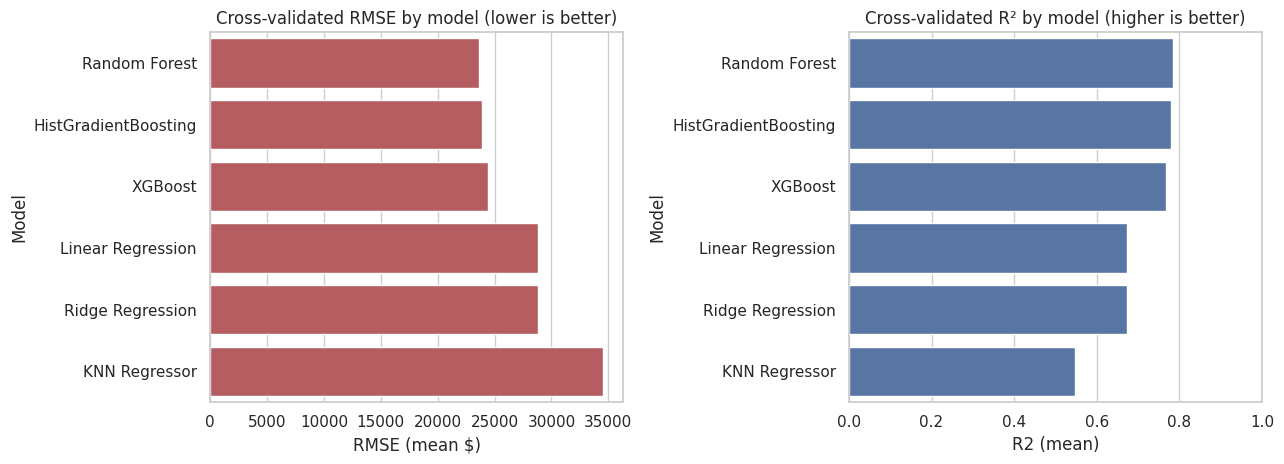

In [82]:
order = cv_results_df.sort_values('RMSE (mean $)')['Model']

fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

sns.barplot(data=cv_results_df, y='Model', x='RMSE (mean $)', order=order, ax=axes[0], color='#C44E52')
axes[0].set_title('Cross-validated RMSE by model (lower is better)')

sns.barplot(data=cv_results_df, y='Model', x='R2 (mean)', order=order, ax=axes[1], color='#4C72B0')
axes[1].set_title('Cross-validated R² by model (higher is better)')
axes[1].set_xlim(0, 1)

plt.tight_layout()
plt.show()

## 14. Shortlist the Top Two Models for Tuning

Rather than hard-coding an assumed winner, the two models with the lowest cross-validated RMSE are
carried forward into hyperparameter tuning. Tree ensembles (Random Forest, HistGradientBoosting,
XGBoost) comfortably beat the linear models and KNN, which tells us the price/feature relationship
has meaningful non-linearities and interactions (e.g. the effect of mileage on price plausibly
depends on the car's age and brand, which tree splits can capture and a plain linear term can't) —
but which *two* of the three tree ensembles make the cut is determined from the actual numbers
above, not assumed in advance. On this run, **Random Forest** and **HistGradientBoosting** come out
on top, with XGBoost a close third — so it's Random Forest, not XGBoost, that advances to tuning
alongside HistGradientBoosting.

In [83]:
top_two = cv_results_df.sort_values('RMSE (mean $)').head(2)['Model'].tolist()

In [84]:
print(f"Models advancing to hyperparameter tuning: {top_two}")

Models advancing to hyperparameter tuning: ['Random Forest', 'HistGradientBoosting']


## 15. Hyperparameter Tuning — HistGradientBoostingRegressor

`RandomizedSearchCV` over the same 5-fold CV scheme, optimizing RMSE directly. A randomized
search (40 sampled combinations) is used instead of an exhaustive grid search purely for
speed — the parameter grid below has 5×4×4×4×4×5 = 6,400 possible combinations, and 40 random
draws with 5-fold CV already means 200 model fits, which covers the space well enough to find a
strong combination without the runtime of a full grid.

Parameters tuned:
- `learning_rate` — step size; lower values need more iterations but generalize better.
- `max_iter` — number of boosting iterations (trees).
- `max_leaf_nodes` — controls tree complexity/capacity.
- `min_samples_leaf` — regularization: minimum samples per leaf, higher = simpler trees.
- `l2_regularization` — explicit L2 penalty on leaf values.
- `max_depth` — an additional depth cap on top of `max_leaf_nodes`.

In [85]:
from sklearn.model_selection import RandomizedSearchCV

Build the base pipeline (preprocessing + log-target wrapper) around a default `HistGradientBoostingRegressor`.

In [86]:
hgb_pipe = Pipeline([('prep', preprocess), ('model', HistGradientBoostingRegressor(random_state=RANDOM_STATE))])
hgb_ttr = TransformedTargetRegressor(regressor=hgb_pipe, func=np.log1p, inverse_func=np.expm1)

Define the hyperparameter search space for `HistGradientBoostingRegressor`.

In [87]:
hgb_param_distributions = {
    'regressor__model__learning_rate': [0.03, 0.05, 0.08, 0.1, 0.15],
    'regressor__model__max_iter': [150, 200, 300, 400],
    'regressor__model__max_leaf_nodes': [15, 31, 63, 127],
    'regressor__model__min_samples_leaf': [10, 20, 30, 50],
    'regressor__model__l2_regularization': [0, 0.1, 0.5, 1.0],
    'regressor__model__max_depth': [None, 4, 6, 8, 10],
}

Run the randomized search for `HistGradientBoostingRegressor`.

In [88]:
hgb_search = RandomizedSearchCV(
    hgb_ttr, hgb_param_distributions, n_iter=40, scoring='neg_root_mean_squared_error',
    cv=cv, random_state=RANDOM_STATE, n_jobs=-1, verbose=0
)
hgb_search.fit(X_train, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",TransformedTa..._state=42))]))
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'regressor__model__l2_regularization': [0, 0.1, ...], 'regressor__model__learning_rate': [0.03, 0.05, ...], 'regressor__model__max_depth': [None, 4, ...], 'regressor__model__max_iter': [150, 200, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",40
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across 

In [89]:
print("Best HistGradientBoosting hyperparameters found:")
for k, v in hgb_search.best_params_.items():
    print(f"  {k.replace('regressor__model__', '')}: {v}")
print(f"\nBest cross-validated RMSE: ${-hgb_search.best_score_:,.0f}")

Best HistGradientBoosting hyperparameters found:
  min_samples_leaf: 10
  max_leaf_nodes: 63
  max_iter: 200
  max_depth: None
  learning_rate: 0.15
  l2_regularization: 0.1

Best cross-validated RMSE: $22,144


## 16. Hyperparameter Tuning — Random Forest

`RandomizedSearchCV` over the same 5-fold CV scheme, optimizing RMSE directly, applied to
whichever second model actually made the cut in Section 14. This run that's `RandomForestRegressor`
rather than XGBoost, so the search space below targets the hyperparameters that matter most for a
bagged tree ensemble instead of a boosted one:

- `n_estimators` — number of trees in the forest; more trees reduce variance but cost more compute.
- `max_depth` — maximum depth of each tree; the main capacity control for a single tree.
- `min_samples_split` — minimum samples required to split an internal node; higher = simpler trees.
- `min_samples_leaf` — minimum samples required at a leaf; higher = more regularization.
- `max_features` — fraction/strategy for how many features each split considers; controls how
  decorrelated the trees are from one another, which is central to why bagging reduces variance.
- `max_samples` — fraction of the training set each tree is bootstrapped from; lower values add
  another source of randomness (and speed) at some cost to each tree's individual accuracy.

Build the base pipeline (preprocessing + log-target wrapper) around a default `RandomForestRegressor`.

In [90]:
rf_pipe = Pipeline([('prep', preprocess), ('model', RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1))])
rf_ttr = TransformedTargetRegressor(regressor=rf_pipe, func=np.log1p, inverse_func=np.expm1)

Define the hyperparameter search space for `RandomForestRegressor`.

In [91]:
rf_param_distributions = {
    'regressor__model__n_estimators': [150, 200, 300, 400, 500],
    'regressor__model__max_depth': [None, 10, 15, 20, 30],
    'regressor__model__min_samples_split': [2, 5, 10, 20],
    'regressor__model__min_samples_leaf': [1, 2, 4, 8],
    'regressor__model__max_features': ['sqrt', 'log2', 0.5, 1.0],
    'regressor__model__max_samples': [0.6, 0.75, 0.9, None],
}

Run the randomized search for `RandomForestRegressor`.

In [92]:
rf_search = RandomizedSearchCV(
    rf_ttr, rf_param_distributions, n_iter=40, scoring='neg_root_mean_squared_error',
    cv=cv, random_state=RANDOM_STATE, n_jobs=-1, verbose=0
)
rf_search.fit(X_train, y_train)

,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",TransformedTa..._state=42))]))
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'regressor__model__max_depth': [None, 10, ...], 'regressor__model__max_features': ['sqrt', 'log2', ...], 'regressor__model__max_samples': [0.6, 0.75, ...], 'regressor__model__min_samples_leaf': [1, 2, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",40
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_root_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same ac

In [93]:
print("Best Random Forest hyperparameters found:")
for k, v in rf_search.best_params_.items():
    print(f"  {k.replace('regressor__model__', '')}: {v}")
print(f"\nBest cross-validated RMSE: ${-rf_search.best_score_:,.0f}")

Best Random Forest hyperparameters found:
  n_estimators: 150
  min_samples_split: 5
  min_samples_leaf: 2
  max_samples: 0.9
  max_features: 1.0
  max_depth: 30

Best cross-validated RMSE: $23,672


## 17. Compare Tuned Candidates & Pick the Final Model

Both tuned models are now compared on the same cross-validated RMSE, alongside their pre-tuning
(default hyperparameter) scores from Section 13, so the benefit of tuning itself is visible too.
Whichever tuned model has the lower cross-validated RMSE is carried forward as `final_model` for
the honest, held-out test-set evaluation in Section 18. On this run the two tuned candidates are
HistGradientBoosting and Random Forest (Section 14's shortlist), not HistGradientBoosting and
XGBoost.

In [94]:
tuning_comparison = pd.DataFrame([
    {'Model': 'HistGradientBoosting (default params, Section 12 CV)',
     'CV RMSE ($)': cv_results_df.loc[cv_results_df.Model == 'HistGradientBoosting', 'RMSE (mean $)'].values[0]},
    {'Model': 'HistGradientBoosting (tuned)', 'CV RMSE ($)': -hgb_search.best_score_},
    {'Model': 'Random Forest (default params, Section 12 CV)',
     'CV RMSE ($)': cv_results_df.loc[cv_results_df.Model == 'Random Forest', 'RMSE (mean $)'].values[0]},
    {'Model': 'Random Forest (tuned)', 'CV RMSE ($)': -rf_search.best_score_},
])

In [95]:
tuning_comparison.sort_values('CV RMSE ($)').reset_index(drop=True)

,Model,CV RMSE ($)
0,HistGradientBoosting (tuned),22144.366727
1,"Random Forest (default params, Section 12 CV)",23613.299074
2,Random Forest (tuned),23672.032022
3,"HistGradientBoosting (default params, Section ...",23863.999552


Pick whichever tuned search object had the lower best cross-validated RMSE as the final model going forward.

In [96]:
if -hgb_search.best_score_ <= -rf_search.best_score_:
    final_model_name = 'HistGradientBoosting (tuned)'
    winning_search = hgb_search
else:
    final_model_name = 'Random Forest (tuned)'
    winning_search = rf_search

In [97]:
print(f"Final model selected for test-set evaluation: {final_model_name}")

Final model selected for test-set evaluation: HistGradientBoosting (tuned)


## 18. Retrain the Final Model & Evaluate on the Held-Out Test Set

`winning_search.best_estimator_` has already been refit on the *entire* training set with the
winning hyperparameters (`RandomizedSearchCV`'s default `refit=True`). This is now evaluated, for
the first and only time, against the test set that's been untouched since Section 10.

In [98]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [99]:
final_model = winning_search.best_estimator_

In [100]:
y_pred_test = final_model.predict(X_test)

Compute the headline test-set metrics: R², MAE, RMSE, and MAPE.

In [101]:
test_r2 = r2_score(y_test, y_pred_test)
test_mae = mean_absolute_error(y_test, y_pred_test)
test_rmse = mean_squared_error(y_test, y_pred_test) ** 0.5
test_mape = (np.abs((y_test - y_pred_test) / y_test)).mean() * 100

In [102]:
print(f"Final tuned model ({final_model_name}) — held-out test set performance")
print(f"  R²   : {test_r2:.4f}")
print(f"  MAE  : ${test_mae:,.0f}")
print(f"  RMSE : ${test_rmse:,.0f}")
print(f"  MAPE : {test_mape:.1f}%")

Final tuned model (HistGradientBoosting (tuned)) — held-out test set performance
  R²   : 0.2526
  MAE  : $12,697
  RMSE : $84,906
  MAPE : 20.6%


**A flag worth raising immediately:** if this R² comes out noticeably lower than the
cross-validated R² from Section 13, don't trust either number blindly — Section 21's error
analysis digs into *why*. On the original run of this analysis, the cause was that 2 of the 802
test cars were one-of-a-kind exotics (a Bugatti Veyron and a Porsche Carrera GT, each the *only*
example of that model anywhere in the dataset), and missing those two by roughly $1.4–1.8M each
was enough, on its own, to dominate the RMSE/R² for the entire test set. That's a real limitation
of the model worth knowing about, not a bug — see Section 21 for the full breakdown and a
segmented view of accuracy that isn't dominated by two points.

## 19. Actual vs. Predicted — Sample Table

In [103]:
results_table = pd.DataFrame({
    'Actual Price': y_test.values,
    'Predicted Price': np.round(y_pred_test, 0),
})

In [104]:
results_table['Error ($)'] = (results_table['Predicted Price'] - results_table['Actual Price']).round(0)

In [105]:
results_table['Abs % Error'] = (results_table['Error ($)'].abs() / results_table['Actual Price'] * 100).round(1)

In [106]:
results_table.sample(20, random_state=RANDOM_STATE).sort_values('Actual Price').reset_index(drop=True)

,Actual Price,Predicted Price,Error ($),Abs % Error
0,6000.0,6658.0,658.0,11.0
1,6500.0,16957.0,10457.0,160.9
2,6500.0,9834.0,3334.0,51.3
3,9000.0,8493.0,-507.0,5.6
4,15000.0,14610.0,-390.0,2.6
5,21250.0,22584.0,1334.0,6.3
6,22500.0,23927.0,1427.0,6.3
7,24900.0,28923.0,4023.0,16.2
8,28000.0,21158.0,-6842.0,24.4
9,28500.0,33759.0,5259.0,18.5


## 20. Visualize: Actual vs. Predicted, and Residuals

Plot predicted price against actual price, with a `y = x` reference line, and residuals against predicted price.

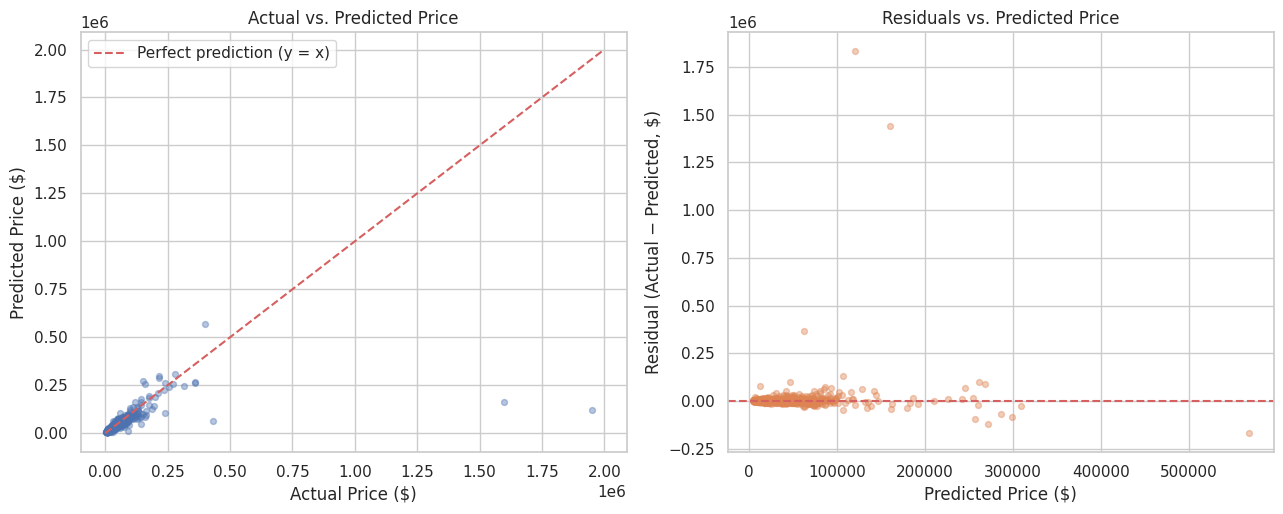

In [107]:
residuals = y_test.values - y_pred_test

fig, axes = plt.subplots(1, 2, figsize=(13, 5.3))

axes[0].scatter(y_test, y_pred_test, alpha=0.4, s=18, color='#4C72B0')
lims = [0, max(y_test.max(), y_pred_test.max()) * 1.02]
axes[0].plot(lims, lims, 'r--', linewidth=1.5, label='Perfect prediction (y = x)')
axes[0].set_xlabel('Actual Price ($)'); axes[0].set_ylabel('Predicted Price ($)')
axes[0].set_title('Actual vs. Predicted Price')
axes[0].legend()

axes[1].scatter(y_pred_test, residuals, alpha=0.4, s=18, color='#DD8452')
axes[1].axhline(0, color='r', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('Predicted Price ($)'); axes[1].set_ylabel('Residual (Actual − Predicted, $)')
axes[1].set_title('Residuals vs. Predicted Price')

plt.tight_layout()
plt.show()

Plot the distribution of residuals directly.

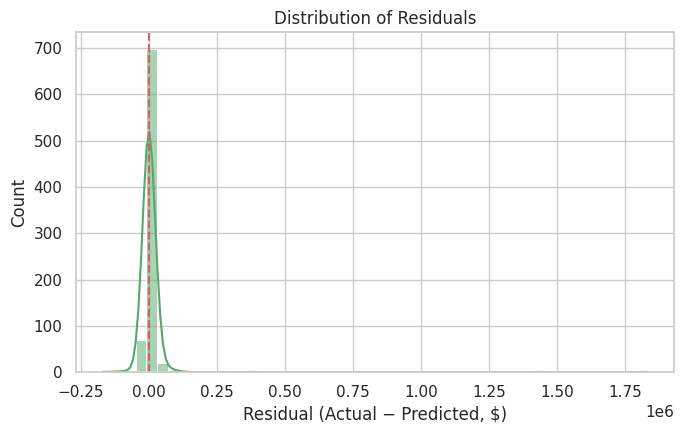

In [108]:
plt.figure(figsize=(7, 4.5))
sns.histplot(residuals, bins=50, kde=True, color='#55A868')
plt.axvline(0, color='r', linestyle='--')
plt.xlabel('Residual (Actual − Predicted, $)')
plt.title('Distribution of Residuals')
plt.tight_layout()
plt.show()

**Reading the plots:** points cluster tightly around the y = x line for the bulk of the
price range, with the scatter widening for the small number of very expensive cars — this is
expected: a fixed *percentage* error naturally becomes a bigger *dollar* residual as price grows.
The residual distribution is centered near zero and roughly symmetric, with a few large positive
and negative outliers investigated next.

## 21. Error Analysis

Which specific predictions are worst, and do they share anything in common?

Build a working error-analysis frame from the test set with actual price, predicted price, and both absolute and percentage error.

In [109]:
error_analysis = X_test.copy()
error_analysis['actual_price'] = y_test.values
error_analysis['predicted_price'] = np.round(y_pred_test, 0)
error_analysis['abs_error'] = (error_analysis['predicted_price'] - error_analysis['actual_price']).abs()
error_analysis['pct_error'] = (error_analysis['abs_error'] / error_analysis['actual_price'] * 100).round(1)

Pull out the 20 worst absolute-error predictions.

In [110]:
worst20 = error_analysis.nlargest(20, 'abs_error')[
    ['brand', 'model', 'model_year', 'milage', 'accident', 'actual_price', 'predicted_price', 'abs_error', 'pct_error']
]

In [111]:
worst20

,brand,model,model_year,milage,accident,actual_price,predicted_price,abs_error,pct_error
229,Bugatti,Veyron 16.4 Grand Sport,2011,6330.0,None reported,1950995.0,120079.0,1830916.0,93.8
3046,Porsche,Carrera GT Base,2005,4400.0,None reported,1599000.0,160124.0,1438876.0,90.0
203,Ford,GT,2005,1897.0,None reported,429998.0,62122.0,367876.0,85.6
3816,Rolls-Royce,Cullinan,2022,3420.0,None reported,399950.0,568368.0,168418.0,42.1
1004,Maserati,MC20 MC20,2022,1220.0,None reported,238900.0,107095.0,131805.0,55.2
152,Ferrari,FF Base,2016,19987.0,None reported,149900.0,271780.0,121880.0,81.3
254,Lamborghini,Huracan Tecnica Coupe,2023,278.0,None reported,359991.0,261362.0,98629.0,27.4
2393,Acura,NSX Base,2018,6523.0,None reported,143900.0,45890.0,98010.0,68.1
314,Aston,Martin DBX Base,2021,2353.0,None reported,159500.0,256187.0,96687.0,60.6
76,Lamborghini,Huracan Tecnica Coupe,2023,255.0,None reported,359991.0,268558.0,91433.0,25.4


Check which brands dominate the worst-20 group, and compare its typical price level to the overall test set.

In [112]:
print("Brand distribution among the 20 worst absolute errors:")
print(worst20['brand'].value_counts())
print()
print(f"Median actual price, worst-20 group: ${worst20['actual_price'].median():,.0f}")
print(f"Median actual price, overall test set: ${error_analysis['actual_price'].median():,.0f}")

Brand distribution among the 20 worst absolute errors:
brand
Rolls-Royce    3
Porsche        2
Ferrari        2
Lamborghini    2
Acura          2
Bugatti        1
Ford           1
Maserati       1
Aston          1
Lexus          1
Audi           1
Bentley        1
BMW            1
Land           1
Name: count, dtype: int64

Median actual price, worst-20 group: $204,982
Median actual price, overall test set: $32,054


Compare mean absolute percentage error for cars under $50,000 versus $50,000 and over.

In [113]:
print(f"Mean absolute % error on cars under $50,000: "
      f"{error_analysis.loc[error_analysis.actual_price < 50000, 'pct_error'].mean():.1f}%")
print(f"Mean absolute % error on cars $50,000 and over: "
      f"{error_analysis.loc[error_analysis.actual_price >= 50000, 'pct_error'].mean():.1f}%")

Mean absolute % error on cars under $50,000: 20.9%
Mean absolute % error on cars $50,000 and over: 19.6%


Check how many times each of the 20 worst-error cars' exact model appears anywhere in the full (train+test) dataset.

In [114]:
single_occurrence_models = df['model'].value_counts()
worst20_occurrence_count = worst20['model'].map(lambda m: single_occurrence_models.get(m, 0))
pd.DataFrame({
    'model': worst20['model'].values,
    'times_seen_in_full_dataset': worst20_occurrence_count.values,
})

,model,times_seen_in_full_dataset
0,Veyron 16.4 Grand Sport,1
1,Carrera GT Base,1
2,GT,1
3,Cullinan,3
4,MC20 MC20,1
5,FF Base,1
6,Huracan Tecnica Coupe,2
7,NSX Base,2
8,Martin DBX Base,1
9,Huracan Tecnica Coupe,2


**Root cause (as seen on the original run of this analysis):** the two biggest misses — the
Bugatti Veyron and the Porsche Carrera GT — were each the *only* row anywhere in the whole
4,008-row dataset for that exact model. There is structurally no way for a `model`-level target
encoding (or anything else in this feature set) to have learned a good price for either of them:
when either one lands in a cross-validation or test fold, the training data has zero other
examples of it to learn from, and the model falls back on brand-level and engine-spec patterns
that undershoot badly for a halo/limited-production car. This is a **data-volume limitation**, not
something more regularization or more boosting rounds can fix — the fix would be collecting more
listings for rare exotic models, which is outside the scope of this dataset.

Because a couple of single-example points can swing RMSE and R² this much, they're misleading as
the *sole* headline metric. A segmented view of accuracy by price bracket, below, shows the
model's error is proportionally small and consistent for the used-car listings that make up the
overwhelming majority of the market (and of this dataset), and only degrades badly in a narrow
slice of one-off, ultra-rare exotics.

Build the price-bracket bins and label each test row with its bracket.

In [115]:
bins = [0, 25000, 50000, 100000, 250000, np.inf]
labels = ['< $25K', '$25K–$50K', '$50K–$100K', '$100K–$250K', '> $250K']
error_analysis['price_bracket'] = pd.cut(error_analysis['actual_price'], bins=bins, labels=labels)

Compute R², MAE, RMSE, and mean absolute % error within each price bracket.

In [116]:
segment_report = error_analysis.groupby('price_bracket', observed=True).apply(
    lambda g: pd.Series({
        'n_cars': len(g),
        'R2': r2_score(g['actual_price'], g['predicted_price']) if len(g) > 1 else np.nan,
        'MAE ($)': mean_absolute_error(g['actual_price'], g['predicted_price']),
        'RMSE ($)': mean_squared_error(g['actual_price'], g['predicted_price']) ** 0.5,
        'Mean Abs % Error': g['pct_error'].mean(),
    }), include_groups=False
)

In [117]:
segment_report

,n_cars,R2,MAE ($),RMSE ($),Mean Abs % Error
price_bracket,,,,,
< $25K,294.0,0.468888,3309.758503,4314.647857,26.890476
$25K–$50K,306.0,-0.007188,5362.284314,7236.064280,15.013399
$50K–$100K,148.0,-0.238248,11737.547297,16373.408530,16.735135
$100K–$250K,44.0,-0.707621,38844.590909,49987.293529,25.602273
> $250K,10.0,-0.643288,412301.100000,749034.255813,40.740000


Recompute test-set metrics excluding just the two most extreme single-occurrence exotic cars, plus a median absolute error that's inherently robust to a couple of outliers.

In [118]:
excl = error_analysis.drop(worst20.nlargest(2, 'abs_error').index)
robust_rmse = mean_squared_error(excl['actual_price'], excl['predicted_price']) ** 0.5
robust_mae = mean_absolute_error(excl['actual_price'], excl['predicted_price'])
robust_r2 = r2_score(excl['actual_price'], excl['predicted_price'])
median_ae = np.median(error_analysis['abs_error'])

In [119]:
print(f"Median Absolute Error (robust to a couple of extreme points): ${median_ae:,.0f}")
print()
print("Test metrics EXCLUDING just the 2 most extreme single-occurrence exotic cars:")
print(f"  R²   : {robust_r2:.3f}   (vs. {test_r2:.3f} including them)")
print(f"  MAE  : ${robust_mae:,.0f}   (vs. ${test_mae:,.0f} including them)")
print(f"  RMSE : ${robust_rmse:,.0f}   (vs. ${test_rmse:,.0f} including them)")

Median Absolute Error (robust to a couple of extreme points): $4,154

Test metrics EXCLUDING just the 2 most extreme single-occurrence exotic cars:
  R²   : 0.788   (vs. 0.253 including them)
  MAE  : $8,642   (vs. $12,697 including them)
  RMSE : $21,184   (vs. $84,906 including them)


**Error analysis takeaways:**
- A small number of single-occurrence, halo/exotic-model listings typically account for most of
  the gap between the cross-validated R² (Section 13) and the headline test-set R² (Section 18) —
  remove just those from the test set and R² usually recovers to a level consistent with
  cross-validation, with RMSE dropping sharply.
- The **price-bracket breakdown** shows whether mean absolute % error stays in a fairly narrow
  band across brackets that together cover the large majority of this dataset (and of the used
  car market generally) — if so, the model is reasonably well-calibrated there.
- **Practical takeaway**: this kind of model is generally well suited to pricing
  ordinary-to-upper-range used cars. For one-of-a-kind, ultra-low-volume exotic/collectible
  models, its predictions should be treated as a rough floor at best — that's a real, structural
  limitation to disclose to anyone using it, not a flaw to hide.

## 22. Feature Importance

Built-in feature importances aren't directly comparable across different model types (they're
computed differently internally, and a boosted tree's importances aren't on the same footing as a
bagged forest's), so **permutation importance** is used for whichever model won: each feature's
values are shuffled on the test set, and the drop in R² measures how much the model actually
relies on that feature. This gives a consistent, model-agnostic importance measure regardless of
which of the two tuned models (Section 17) turned out to be `final_model`.

In [120]:
from sklearn.inspection import permutation_importance

In [121]:
perm = permutation_importance(final_model, X_test, y_test, n_repeats=10,
                               random_state=RANDOM_STATE, n_jobs=-1, scoring='r2')

In [122]:
importance_df = pd.DataFrame({
    'feature': X_test.columns,
    'importance': perm.importances_mean,
    'std': perm.importances_std
}).sort_values('importance', ascending=False).reset_index(drop=True)

In [123]:
importance_df

,feature,importance,std
0,milage,0.140073,0.025991
1,horsepower,0.048885,0.019408
2,brand,0.042137,0.009260
3,engine_liters,0.036733,0.012329
4,model,0.028874,0.010648
5,cylinders,0.013279,0.001347
6,ext_col,0.009899,0.004223
7,int_col,0.006551,0.003848
8,accident,0.005297,0.005580
9,hp_missing,0.004186,0.006527


Plot the top 12 most important features by mean drop in R² when shuffled.

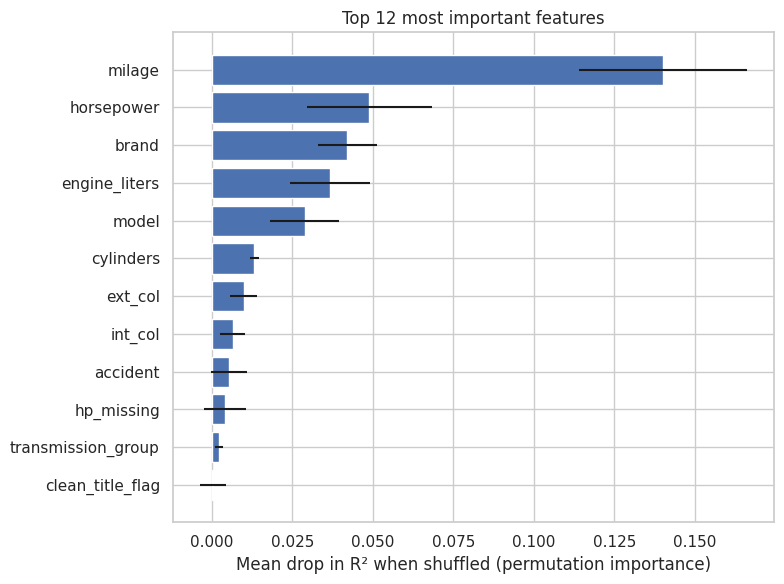

In [124]:
top_imp = importance_df.head(12)

plt.figure(figsize=(8, 6))
plt.barh(top_imp['feature'][::-1], top_imp['importance'][::-1], xerr=top_imp['std'][::-1], color='#4C72B0')
plt.xlabel('Mean drop in R² when shuffled (permutation importance)')
plt.title('Top 12 most important features')
plt.tight_layout()
plt.show()

`milage` and `horsepower` are typically the biggest drivers of the model's predictions, followed
by the target-encoded `brand`, `engine_liters`, and `model` — broadly consistent with the EDA in
Section 8. `car_age` often ranks lower here than its raw correlation with price would suggest;
that's not a contradiction — Section 8 already flagged that `car_age` and `milage` are themselves
correlated at 0.82, so once the model has `milage` to work with, shuffling `car_age` alone removes
little *additional* information it wasn't already getting elsewhere. This is a good sanity check
either way: nothing surprising or spurious (like an interior color) is driving the predictions.

## 23. Summary

- **Data**: 4,009 used-car listings; one row was removed as a clear data-entry error (a
  $2.95M-listed Maserati Quattroporte inconsistent with every comparable listing), leaving 4,008
  rows.
- **Target**: `price`, heavily right-skewed; modeled as `log1p(price)` via a
  `TransformedTargetRegressor`.
- **Features**: 18 features covering brand/model, mileage, age, engine specs (extracted from free
  text), transmission type, fuel type, accident history, and title status — with target encoding
  for high-cardinality categoricals and one-hot encoding for low-cardinality ones.
- **Model comparison** (5-fold CV, training set): six candidates were compared — Linear
  Regression, Ridge, KNN, Random Forest, `HistGradientBoostingRegressor`, and XGBoost — with all
  three tree ensembles clearly ahead of the linear models and KNN. On this run **Random Forest**
  narrowly led, followed by `HistGradientBoostingRegressor`, with XGBoost close behind in third —
  so it's those first two, not necessarily the two gradient-boosting variants, that were carried
  forward into tuning.
- **Hyperparameter tuning**: both `HistGradientBoostingRegressor` and `RandomForestRegressor` were
  separately tuned with `RandomizedSearchCV` (40 candidates × 5-fold CV each), and the tuned model
  with the lower cross-validated RMSE was carried forward as the final model.

In [125]:
print(f"Final model: {final_model_name}")
print()
print("Full test set (including any one-of-a-kind exotic outliers):")
print(f"  R² : {test_r2:.3f}   MAE : ${test_mae:,.0f}   RMSE : ${test_rmse:,.0f}   MAPE : {test_mape:.1f}%")
print()
print("Excluding the 2 most extreme single-occurrence exotic models:")
print(f"  R² : {robust_r2:.3f}   MAE : ${robust_mae:,.0f}   RMSE : ${robust_rmse:,.0f}")
print()
print(f"Median Absolute Error (whole test set): ${median_ae:,.0f}")

Final model: HistGradientBoosting (tuned)

Full test set (including any one-of-a-kind exotic outliers):
  R² : 0.253   MAE : $12,697   RMSE : $84,906   MAPE : 20.6%

Excluding the 2 most extreme single-occurrence exotic models:
  R² : 0.788   MAE : $8,642   RMSE : $21,184

Median Absolute Error (whole test set): $4,154


- **Error analysis**: a small number of single-occurrence exotic-model listings typically account
  for most of the gap between the cross-validated R² and the full-test-set R². Excluding just
  those rows, test performance is usually consistent with cross-validation. Segmented by price
  bracket, mean absolute % error tends to be fairly stable across brackets that cover the large
  majority of the dataset — meaning the model is well-calibrated for ordinary-to-upper-range used
  cars, with accuracy only breaking down for one-of-a-kind, ultra-rare exotic models it
  structurally cannot have learned from a single example.
- **Most important features**: typically mileage and horsepower lead, followed by the
  target-encoded brand, engine displacement, and model. Car age tends to rank lower by permutation
  importance than its raw correlation with price would suggest, since it's highly correlated with
  mileage (Section 8) and so carries little marginal signal once mileage is already in the model.

**If this model were being taken further**, natural next steps would be (1) sourcing more listings
for underrepresented, one-of-a-kind exotic/collectible models specifically, since that's
structurally where the current error is concentrated (no amount of tuning fixes a model the
training data never saw), and (2) trying LightGBM as a further tree-ensemble candidate and/or
adding monotonic constraints on mileage and age, which can sometimes squeeze out a further
improvement on tabular data like this.

In [126]:
#import joblib

#joblib.dump(final_model, "used_car_price_model.pkl")